In [ ]:
# Mount google drive to current runtime session to access required files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import Libraries
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [ ]:
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.10.0+cu128
True
NVIDIA A100-SXM4-40GB


In [ ]:
# Import spectrogram zip to local storage for efficient loading

shutil.copy('/content/drive/MyDrive/DSAN6600 Project/piano_roll.zip',
            '/content/piano_roll.zip')

'/content/piano_roll.zip'

In [ ]:
# Unzip spectrogram file to extract all 150,000 npy files
!unzip -q piano_roll.zip -d /content/piano_roll

In [ ]:
# Size of spectrogram folder and number of npy files
!du -sh /content/piano_roll/piano_roll/*
!find /content/piano_roll/piano_roll/ -type f | wc -l

/bin/bash: line 1: /usr/bin/du: Argument list too long
150014


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/DSAN6600 Project/lmd_full_metadata.csv')

# Filter out missing keys
df = df[df['key_name'].notna() & (df['key_name'] != '')]

# Filter major keys only
df = df[df['key_name'].str.contains('major')]

print(f"Total usable samples: {len(df)}")
print(f"Key distribution:\n{df['key_name'].value_counts()}")

Total usable samples: 93478
Key distribution:
key_name
C major     59720
G major      6836
F major      5821
D major      4520
A# major     3707
D# major     3560
A major      3025
E major      2291
G# major     1807
C# major     1050
B major       618
F# major      523
Name: count, dtype: int64


In [ ]:
# Cap C major at 4500
df_c = df[df['key_name'] == 'C major'].sample(4500, random_state=42)
df_others = df[df['key_name'] != 'C major']

# Combine and drop keys with less than 1000 samples
df_balanced = pd.concat([df_c, df_others])
df_balanced = df_balanced.groupby('key_name').filter(lambda x: len(x) >= 1000)

print(df_balanced['key_name'].value_counts())
print(f"Total samples: {len(df_balanced)}")
print(f"Total classes: {df_balanced['key_name'].nunique()}")

key_name
G major     6836
F major     5821
D major     4520
C major     4500
A# major    3707
D# major    3560
A major     3025
E major     2291
G# major    1807
C# major    1050
Name: count, dtype: int64
Total samples: 37117
Total classes: 10


In [ ]:
# Convert keys to integers for labeling purposes
key_to_idx = {key: idx for idx, key in enumerate(sorted(df_balanced['key_name'].unique()))}
idx_to_key = {idx: key for key, idx in key_to_idx.items()}

print(key_to_idx)
# {'A major': 0, 'A# major': 1, 'C major': 2, ...}

df_balanced['label'] = df_balanced['key_name'].map(key_to_idx)

df_balanced.head()

{'A major': 0, 'A# major': 1, 'C major': 2, 'C# major': 3, 'D major': 4, 'D# major': 5, 'E major': 6, 'F major': 7, 'G major': 8, 'G# major': 9}


,file,filepath,duration_s,resolution,n_instruments,n_notes,n_tempo_changes,initial_bpm,n_key_changes,initial_key,n_time_sig_changes,initial_time_sig,key_name,label
70182,2c877e367d9ecae70c59f9a1fafff7b6.mid,../data/raw_data/lmd_full/2/2c877e367d9ecae70c...,17.35,384,4,191,1,83.0,1,0.0,1,4/4,C major,2
147776,5c513934243de942f6b27b4383403f1f.mid,../data/raw_data/lmd_full/5/5c513934243de942f6...,203.91,480,15,6463,1,133.0,1,0.0,1,4/4,C major,2
132351,19684ed364581e059e7645042b607c86.mid,../data/raw_data/lmd_full/1/19684ed364581e059e...,359.91,240,11,5510,1,80.0,1,0.0,1,4/4,C major,2
88719,065ba7baee7cda0903cceb2c54404395.mid,../data/raw_data/lmd_full/0/065ba7baee7cda0903...,189.71,480,7,3059,2,70.0,1,0.0,1,4/4,C major,2
82806,ba68ba35a4bf1a58dc2619ac72509c8f.mid,../data/raw_data/lmd_full/b/ba68ba35a4bf1a58dc...,60.78,480,1,995,1,165.0,1,0.0,1,4/4,C major,2


In [ ]:
df_balanced['npy_file'] = df_balanced['file'].str.replace("mid","npy")

# Build full file paths
data_dir = '/content/piano_roll/piano_roll/'
df_balanced['file_path'] = data_dir + df_balanced['npy_file']

In [ ]:
sample = df_balanced['file_path'].iloc[1]
print(f"Example path: {sample}")
print(f"File exists: {os.path.exists(sample)}")

Example path: /content/piano_roll/piano_roll/5c513934243de942f6b27b4383403f1f.npy
File exists: True


In [ ]:
# Check which files actually exist
df_balanced['file_exists'] = df_balanced['file_path'].apply(os.path.exists)

print(f"Files found:   {df_balanced['file_exists'].sum()}")
print(f"Files missing: {(~df_balanced['file_exists']).sum()}")

# Keep only existing files
df_balanced = df_balanced[df_balanced['file_exists']]

df_balanced = df_balanced[df_balanced['file_path'].apply(
    lambda p: np.load(p).shape == (128, 468)
)]

print(f"Remaining samples after removing different shapes: {len(df_balanced)}")

Files found:   36112
Files missing: 1005
Remaining samples after removing different shapes: 36112


In [ ]:
sample = np.load('/content/piano_roll/piano_roll/deeb8ab7a04e5360231fb5019d847b1a.npy')
print(f"Shape: {sample.shape}")
print(f"Dtype: {sample.dtype}")
print(f"Min: {sample.min():.4f}, Max: {sample.max():.4f}")

Shape: (128, 468)
Dtype: uint8
Min: 0.0000, Max: 114.0000


In [ ]:
class PianoRollDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        x = np.load(self.file_paths[idx]).astype(np.float32)
        # Piano rolls are binary/velocity values in [0, 127] — normalize to [0, 1]
        # (x + 80) / 80 was spectrogram-specific and is incorrect here
        x = x / 127.0
        x = x[np.newaxis, :, :]              # add channel dim → (1, 128, 468)
        return torch.tensor(x), torch.tensor(self.labels[idx])

In [ ]:
file_paths = df_balanced['file_path'].tolist()
labels = df_balanced['label'].tolist()

# Split into train/val
X_train, X_val, y_train, y_val = train_test_split(
    file_paths, labels,
    test_size=0.3,
    random_state=42,
    stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_val, y_val,
    test_size=0.5,
    random_state=42,
    stratify=y_val
)

train_dataset = PianoRollDataset(X_train, y_train)
val_dataset   = PianoRollDataset(X_val,   y_val)
test_dataset  = PianoRollDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False,
                          num_workers=4, pin_memory=True)

# Training

In [ ]:
import torch.nn as nn

class GeneralCNN(nn.Module):
  def __init__(self, num_classes = 10):
    super().__init__()

    self.features = nn.Sequential(
        nn.Conv2d(1,32,kernel_size=3,padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(32, 64, 3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(64, 128, kernel_size = 3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(128, 256, kernel_size = 3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

      )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(256*8*29, 512),
        nn.ReLU(),
        nn.Dropout(.3),
        nn.Linear(512,256),
        nn.ReLU(),
        nn.Dropout(.3),
        nn.Linear(256, num_classes)
    )

  def forward(self, x):
      x = self.features(x)
      x = self.classifier(x)
      return x

model = GeneralCNN(num_classes=10).cuda()
print(model)

GeneralCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

In [ ]:
class EarlyStopper:
    def __init__(self, patience=4, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_val_acc = 0

    def early_stop(self, validation_acc):
        if validation_acc > self.best_val_acc + self.min_delta:
            self.best_val_acc = validation_acc
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

In [ ]:
import torch.optim as optim
from torch.amp import GradScaler, autocast

import time

start = time.time()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scaler = GradScaler('cuda')
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.7)
early_stopper = EarlyStopper(patience=3, min_delta=.25)

CHECKPOINT_PATH = '/content/drive/MyDrive/cnn_model_output/piano_class_.pth'

for epoch in range(20):
    # --- Training ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.cuda(), labels.cuda()
        optimizer.zero_grad()

        with autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    train_acc = 100. * correct / total

    # --- Validation ---
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.cuda(), labels.cuda()
            outputs = model(images)
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total += labels.size(0)

    val_acc = 100. * val_correct / val_total

    # --- Checkpoint ---
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, CHECKPOINT_PATH)

    # --- Save best model separately ---
    if val_acc > early_stopper.best_val_acc:
        torch.save(model.state_dict(), '/content/drive/MyDrive/cnn_model_output/best_model_piano_class_CNN.pth')

    print(f"Epoch {epoch+1:2d}/25 | Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}%")
    scheduler.step()
    print(f"LR: {scheduler.get_last_lr()[0]:.6f}")

    if early_stopper.early_stop(val_acc):
      print(f"EARLY STOPPING AT EPOCH {epoch+1:2d}, best val: {early_stopper.best_val_acc:.1f}%")
      break

end = time.time()
print(f"Total training time: {(end-start)/60:.1f} minutes")

Epoch  1/25 | Loss: 1.6255 | Train Acc: 44.0% | Val Acc: 64.0%
LR: 0.000100
Epoch  2/25 | Loss: 1.0378 | Train Acc: 68.3% | Val Acc: 71.5%
LR: 0.000100
Epoch  3/25 | Loss: 0.9461 | Train Acc: 71.4% | Val Acc: 75.1%
LR: 0.000100
Epoch  4/25 | Loss: 0.8920 | Train Acc: 73.2% | Val Acc: 74.3%
LR: 0.000100
Epoch  5/25 | Loss: 0.8384 | Train Acc: 74.8% | Val Acc: 73.7%
LR: 0.000070
Epoch  6/25 | Loss: 0.7806 | Train Acc: 76.6% | Val Acc: 75.4%
LR: 0.000070
Epoch  7/25 | Loss: 0.7380 | Train Acc: 77.8% | Val Acc: 77.7%
LR: 0.000070
Epoch  8/25 | Loss: 0.7080 | Train Acc: 78.4% | Val Acc: 76.1%
LR: 0.000070
Epoch  9/25 | Loss: 0.6740 | Train Acc: 79.5% | Val Acc: 78.2%
LR: 0.000070
Epoch 10/25 | Loss: 0.6396 | Train Acc: 80.3% | Val Acc: 77.8%
LR: 0.000049
Epoch 11/25 | Loss: 0.5857 | Train Acc: 81.9% | Val Acc: 78.6%
LR: 0.000049
Epoch 12/25 | Loss: 0.5575 | Train Acc: 82.4% | Val Acc: 77.6%
LR: 0.000049
Epoch 13/25 | Loss: 0.5259 | Train Acc: 83.3% | Val Acc: 76.6%
LR: 0.000049
Epoch 14/25 

# Evaluating against test set

In [ ]:
# Evaluating model against test
model = GeneralCNN(num_classes=10).cuda()
model.load_state_dict(torch.load('/content/drive/MyDrive/cnn_model_output/best_model_piano_class_CNN.pth'))
model.eval()

# Dataloader for test data
test_dataset = PianoRollDataset(X_test, y_test)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

test_correct, test_total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.cuda(), labels.cuda()
        outputs = model(images)
        _, predicted = outputs.max(1)
        test_correct += predicted.eq(labels).sum().item()
        test_total   += labels.size(0)

test_acc = 100. * test_correct / test_total
print(f"Test Accuracy: {test_acc:.1f}%")

Test Accuracy: 78.1%


In [ ]:
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.cuda(), labels.cuda()
        outputs = model(images)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"Total predictions: {len(all_preds)}")

Total predictions: 5417


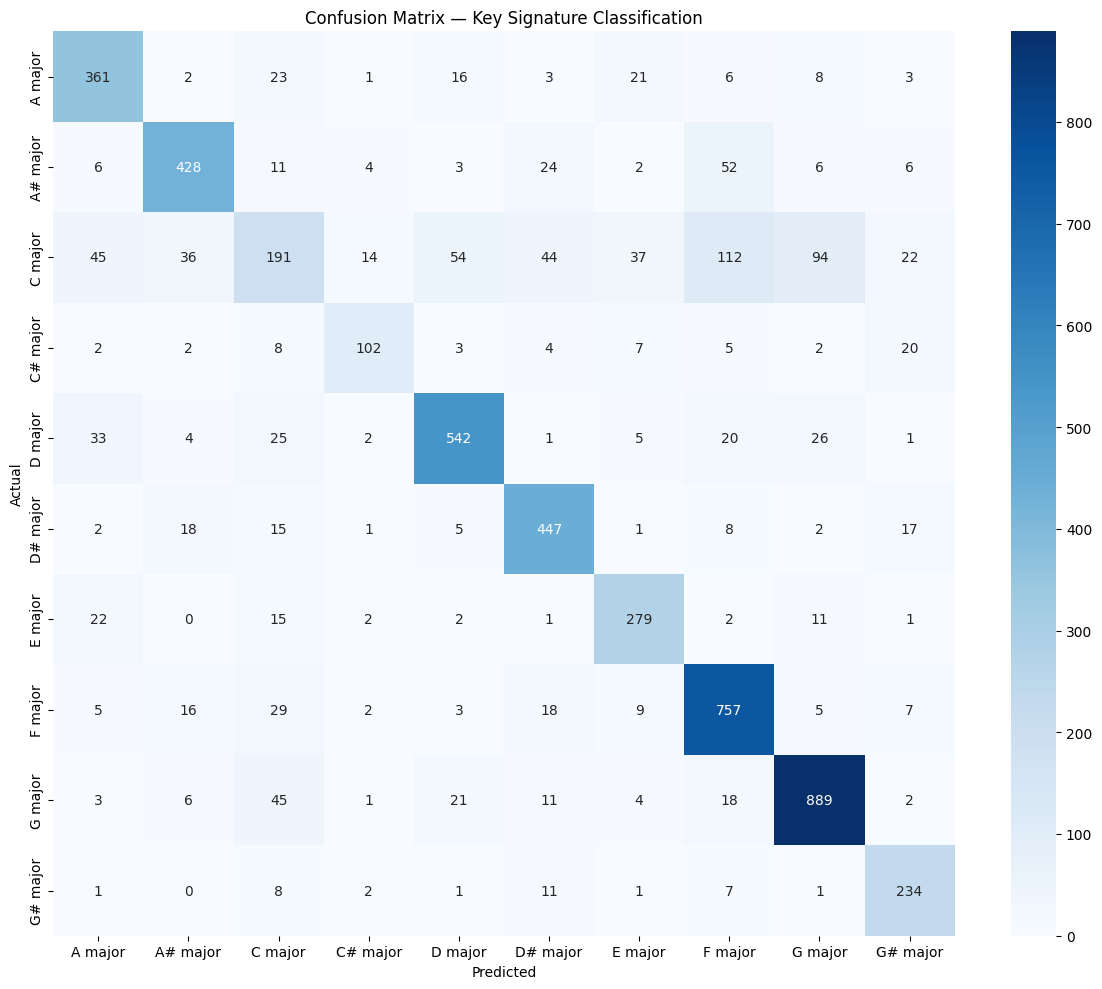

In [ ]:
key_names = [idx_to_key[i] for i in range(len(idx_to_key))]

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=key_names,
            yticklabels=key_names,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Key Signature Classification')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cnn_model_output/confusion_matrix_piano_class_CNN.png')
plt.show()